In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


In [2]:
SIM_COL = "fsq_osm_name_similarity_score_lev"
DIST_COL = "fsq_osm_distance"
CSV_PATH = "../../data/name_similarity_distance_lev.csv"
fig_dir = "../../evaluation/figs-lev"
os.makedirs(fig_dir, exist_ok=True)

In [ ]:
def get_data(
    name_similarity_threshold=0.0,
    distance_threshold=0.0015,
    bins=100,
    chunk_size=1_000_000,
):
    sim_bins = np.linspace(name_similarity_threshold, 1, bins + 1)
    dist_bins = np.linspace(0, distance_threshold, bins + 1)

    sim_counts = np.zeros(bins)
    dist_counts = np.zeros(bins)
    hist2d_counts = np.zeros((bins, bins))

    total_rows_used = 0

    for chunk in pd.read_csv(
        CSV_PATH,
        usecols=[SIM_COL, DIST_COL],
        chunksize=chunk_size
    ):
        chunk = chunk[[SIM_COL, DIST_COL]].dropna()

        sim = chunk[SIM_COL].to_numpy()
        dist = chunk[DIST_COL].to_numpy()

        mask = (
            (sim >= name_similarity_threshold) &
            (sim <= 1) &
            (dist >= 0) &
            (dist <= distance_threshold)
        )

        sim = sim[mask]
        dist = dist[mask]

        total_rows_used += len(sim)

        sim_counts += np.histogram(sim, bins=sim_bins)[0]
        dist_counts += np.histogram(dist, bins=dist_bins)[0]
        hist2d_counts += np.histogram2d(sim, dist, bins=[sim_bins, dist_bins])[0]

    return {
        "sim_bins": sim_bins,
        "dist_bins": dist_bins,
        "sim_counts": sim_counts,
        "dist_counts": dist_counts,
        "hist2d_counts": hist2d_counts,
        "name_similarity_threshold": name_similarity_threshold,
        "distance_threshold": distance_threshold,
        "total_rows_used": total_rows_used,
    }


def plot_(data, output_prefix="filtered", show=True):
    sim_bins = data["sim_bins"]
    dist_bins = data["dist_bins"]
    sim_counts = data["sim_counts"]
    dist_counts = data["dist_counts"]
    hist2d_counts = data["hist2d_counts"]

    name_similarity_threshold = data["name_similarity_threshold"]
    distance_threshold = data["distance_threshold"]
    total_rows_used = data["total_rows_used"]

    print(f"{total_rows_used:,}", end=" & ")

    # Plot 1: name similarity histogram
    plt.figure(figsize=(8, 5))
    plt.bar(
        sim_bins[:-1],
        sim_counts,
        width=np.diff(sim_bins),
        align="edge"
    )
    plt.xlabel("Name similarity score")
    plt.ylabel("Count")
    # plt.title(
    #     f"Name similarity histogram, score > {name_similarity_threshold}, "
    #     f"distance <= {distance_threshold}"
    # )
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/1_similarity_histogram_{output_prefix}.png", dpi=200)

    if show:
        plt.show()
    else:
        plt.close()

    # Plot 2: distance histogram
    plt.figure(figsize=(8, 5))
    plt.bar(
        dist_bins[:-1]*100000,
        dist_counts,
        width=np.diff(dist_bins)*100000,
        align="edge"
    )
    plt.xlabel("Distance (meters)")
    plt.ylabel("Count")
    # plt.title(
    #     f"Distance histogram, score > {name_similarity_threshold}, "
    #     f"distance <= {distance_threshold}"
    # )
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/2_distance_histogram_{output_prefix}.png", dpi=200)

    if show:
        plt.show()
    else:
        plt.close()



In [4]:
distance_map = {"150":0.0015, "125":0.00125, "100":0.001, "75":0.00075, "50":0.0005, "25":0.00025}
data_25_00 = get_data(distance_threshold=distance_map["25"])
data_50_00 = get_data(distance_threshold=distance_map["50"])
data_75_00 = get_data(distance_threshold=distance_map["75"])
data_100_00 = get_data(distance_threshold=distance_map["100"])
data_125_00 = get_data(distance_threshold=distance_map["125"])
data_150_00 = get_data(distance_threshold=distance_map["150"])

In [5]:
data_25_01 = get_data(distance_threshold=distance_map["25"], name_similarity_threshold=0.1)
data_50_01 = get_data(distance_threshold=distance_map["50"], name_similarity_threshold=0.1)
data_75_01 = get_data(distance_threshold=distance_map["75"], name_similarity_threshold=0.1)
data_100_01 = get_data(distance_threshold=distance_map["100"], name_similarity_threshold=0.1)
data_125_01 = get_data(distance_threshold=distance_map["125"], name_similarity_threshold=0.1)
data_150_01 = get_data(distance_threshold=distance_map["150"], name_similarity_threshold=0.1)

In [6]:
data_25_02 = get_data(distance_threshold=distance_map["25"], name_similarity_threshold=0.2)
data_50_02 = get_data(distance_threshold=distance_map["50"], name_similarity_threshold=0.2)
data_75_02 = get_data(distance_threshold=distance_map["75"], name_similarity_threshold=0.2)
data_100_02 = get_data(distance_threshold=distance_map["100"], name_similarity_threshold=0.2)
data_125_02 = get_data(distance_threshold=distance_map["125"], name_similarity_threshold=0.2)
data_150_02 = get_data(distance_threshold=distance_map["150"], name_similarity_threshold=0.2)

In [8]:
data_25_03 = get_data(distance_threshold=distance_map["25"], name_similarity_threshold=0.3)
data_50_03 = get_data(distance_threshold=distance_map["50"], name_similarity_threshold=0.3)
data_75_03 = get_data(distance_threshold=distance_map["75"], name_similarity_threshold=0.3)
data_100_03 = get_data(distance_threshold=distance_map["100"], name_similarity_threshold=0.3)
data_125_03 = get_data(distance_threshold=distance_map["125"], name_similarity_threshold=0.3)
data_150_03 = get_data(distance_threshold=distance_map["150"], name_similarity_threshold=0.3)

In [9]:
data_25_04 = get_data(distance_threshold=distance_map["25"], name_similarity_threshold=0.4)
data_50_04 = get_data(distance_threshold=distance_map["50"], name_similarity_threshold=0.4)
data_75_04 = get_data(distance_threshold=distance_map["75"], name_similarity_threshold=0.4)
data_100_04 = get_data(distance_threshold=distance_map["100"], name_similarity_threshold=0.4)
data_125_04 = get_data(distance_threshold=distance_map["125"], name_similarity_threshold=0.4)
data_150_04 = get_data(distance_threshold=distance_map["150"], name_similarity_threshold=0.4)

In [10]:
data_25_05 = get_data(distance_threshold=distance_map["25"], name_similarity_threshold=0.5)
data_50_05 = get_data(distance_threshold=distance_map["50"], name_similarity_threshold=0.5)
data_75_05 = get_data(distance_threshold=distance_map["75"], name_similarity_threshold=0.5)
data_100_05 = get_data(distance_threshold=distance_map["100"], name_similarity_threshold=0.5)
data_125_05 = get_data(distance_threshold=distance_map["125"], name_similarity_threshold=0.5)
data_150_05 = get_data(distance_threshold=distance_map["150"], name_similarity_threshold=0.5)

In [11]:
data_25_06 = get_data(distance_threshold=distance_map["25"], name_similarity_threshold=0.6)
data_50_06 = get_data(distance_threshold=distance_map["50"], name_similarity_threshold=0.6)
data_75_06 = get_data(distance_threshold=distance_map["75"], name_similarity_threshold=0.6)
data_100_06 = get_data(distance_threshold=distance_map["100"], name_similarity_threshold=0.6)
data_125_06 = get_data(distance_threshold=distance_map["125"], name_similarity_threshold=0.6)
data_150_06 = get_data(distance_threshold=distance_map["150"], name_similarity_threshold=0.6)

In [12]:
data_25_07 = get_data(distance_threshold=distance_map["25"], name_similarity_threshold=0.7)
data_50_07 = get_data(distance_threshold=distance_map["50"], name_similarity_threshold=0.7)
data_75_07 = get_data(distance_threshold=distance_map["75"], name_similarity_threshold=0.7)
data_100_07 = get_data(distance_threshold=distance_map["100"], name_similarity_threshold=0.7)
data_125_07 = get_data(distance_threshold=distance_map["125"], name_similarity_threshold=0.7)
data_150_07 = get_data(distance_threshold=distance_map["150"], name_similarity_threshold=0.7)

In [13]:
data_25_08 = get_data(distance_threshold=distance_map["25"], name_similarity_threshold=0.8)
data_50_08 = get_data(distance_threshold=distance_map["50"], name_similarity_threshold=0.8)
data_75_08 = get_data(distance_threshold=distance_map["75"], name_similarity_threshold=0.8)
data_100_08 = get_data(distance_threshold=distance_map["100"], name_similarity_threshold=0.8)
data_125_08 = get_data(distance_threshold=distance_map["125"], name_similarity_threshold=0.8)
data_150_08 = get_data(distance_threshold=distance_map["150"], name_similarity_threshold=0.8)

In [14]:
data_25_09 = get_data(distance_threshold=distance_map["25"], name_similarity_threshold=0.9)
data_50_09 = get_data(distance_threshold=distance_map["50"], name_similarity_threshold=0.9)
data_75_09 = get_data(distance_threshold=distance_map["75"], name_similarity_threshold=0.9)
data_100_09 = get_data(distance_threshold=distance_map["100"], name_similarity_threshold=0.9)
data_125_09 = get_data(distance_threshold=distance_map["125"], name_similarity_threshold=0.9)
data_150_09 = get_data(distance_threshold=distance_map["150"], name_similarity_threshold=0.9)

In [15]:
data_25_10 = get_data(distance_threshold=distance_map["25"], name_similarity_threshold=1.0)
data_50_10 = get_data(distance_threshold=distance_map["50"], name_similarity_threshold=1.0)
data_75_10 = get_data(distance_threshold=distance_map["75"], name_similarity_threshold=1.0)
data_100_10 = get_data(distance_threshold=distance_map["100"], name_similarity_threshold=1.0)
data_125_10 = get_data(distance_threshold=distance_map["125"], name_similarity_threshold=1.0)
data_150_10 = get_data(distance_threshold=distance_map["150"], name_similarity_threshold=1.0)

In [16]:
data_by_distance_00 = {
    "25": data_25_00,
    "50": data_50_00,
    "75": data_75_00,
    "100": data_100_00,
    "125": data_125_00,
    "150": data_150_00,
}

data_by_distance_01 = {
    "25": data_25_01,
    "50": data_50_01,
    "75": data_75_01,
    "100": data_100_01,
    "125": data_125_01,
    "150": data_150_01,
}

data_by_distance_02 = {
    "25": data_25_02,
    "50": data_50_02,
    "75": data_75_02,
    "100": data_100_02,
    "125": data_125_02,
    "150": data_150_02,
}

data_by_distance_03 = {
    "25": data_25_03,
    "50": data_50_03,
    "75": data_75_03,
    "100": data_100_03,
    "125": data_125_03,
    "150": data_150_03,
}

data_by_distance_04 = {
    "25": data_25_04,
    "50": data_50_04,
    "75": data_75_04,
    "100": data_100_04,
    "125": data_125_04,
    "150": data_150_04,
}
data_by_distance_05 = {
    "25": data_25_05,
    "50": data_50_05,
    "75": data_75_05,
    "100": data_100_05,
    "125": data_125_05,
    "150": data_150_05,
}
data_by_distance_06 = {
    "25": data_25_06,
    "50": data_50_06,
    "75": data_75_06,
    "100": data_100_06,
    "125": data_125_06,
    "150": data_150_06,
}
data_by_distance_07 = {
    "25": data_25_07,
    "50": data_50_07,
    "75": data_75_07,
    "100": data_100_07,
    "125": data_125_07,
    "150": data_150_07,
}
data_by_distance_08 = {
    "25": data_25_08,
    "50": data_50_08,
    "75": data_75_08,
    "100": data_100_08,
    "125": data_125_08,
    "150": data_150_08,
}
data_by_distance_09 = {
    "25": data_25_09,
    "50": data_50_09,
    "75": data_75_09,
    "100": data_100_09,
    "125": data_125_09,
    "150": data_150_09,
}
data_by_distance_10 = {
    "25": data_25_10,
    "50": data_50_10,
    "75": data_75_10,
    "100": data_100_10,
    "125": data_125_10,
    "150": data_150_10,
}

In [30]:

def plot_threshold_comparison(data_by_distance, normalize=False):
    plt.figure(figsize=(9, 5))

    for label, data in data_by_distance.items():
        sim_bins = data["sim_bins"]
        sim_counts = data["sim_counts"]
        bin_centers = (sim_bins[:-1] + sim_bins[1:]) / 2

        y = sim_counts.copy()

        if normalize:
            total = y.sum()
            if total > 0:
                y = y / total

        plt.plot(bin_centers, y, label=f"distance <= {label}")

    plt.xlabel("Name similarity score")
    plt.ylabel("Share of rows" if normalize else "Count")
    # plt.title("Name similarity distribution by distance threshold")
    plt.legend(title="Distance radius (meters)")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/comparison_similarity_by_distance_threshold.png", dpi=200)
    plt.show()


def plot_rows(data_by_distances):
    plt.figure(figsize=(8, 5))
    if not isinstance(data_by_distances, list):
        data_by_distances = [data_by_distances]
    for data_by_distance in data_by_distances:
        labels = list(data_by_distance.keys())
        rows = [data_by_distance[k]["total_rows_used"] for k in labels]
        plt.yscale("log")

        plt.plot(labels, rows, marker="o", label=f"Name similarity > {data_by_distance[next(iter(data_by_distance))]['name_similarity_threshold']}")
    plt.xlabel("Distance Radius (meters)")
    plt.ylabel("Number of Records (log scale)")
    plt.legend(title="Name similarity score")
    # plt.title("Rows by distance threshold")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/rows_by_distance_threshold.png", dpi=200)
    plt.show()


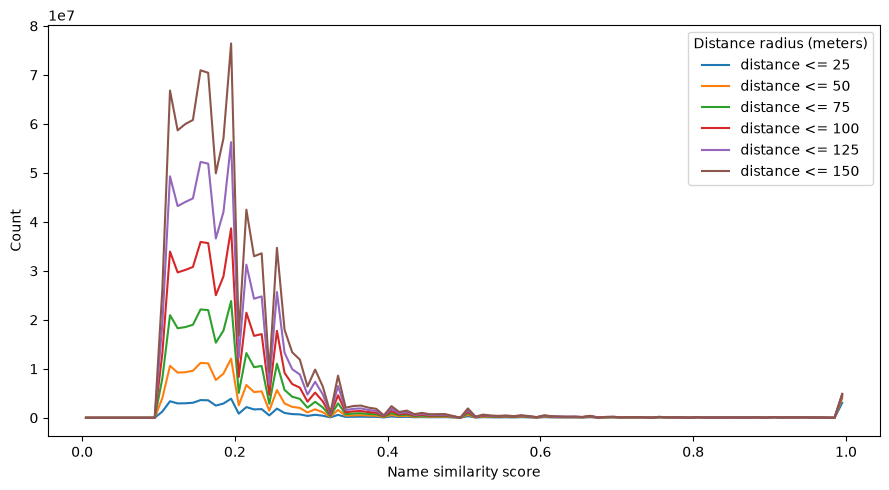

In [18]:
plot_threshold_comparison(data_by_distance_00)

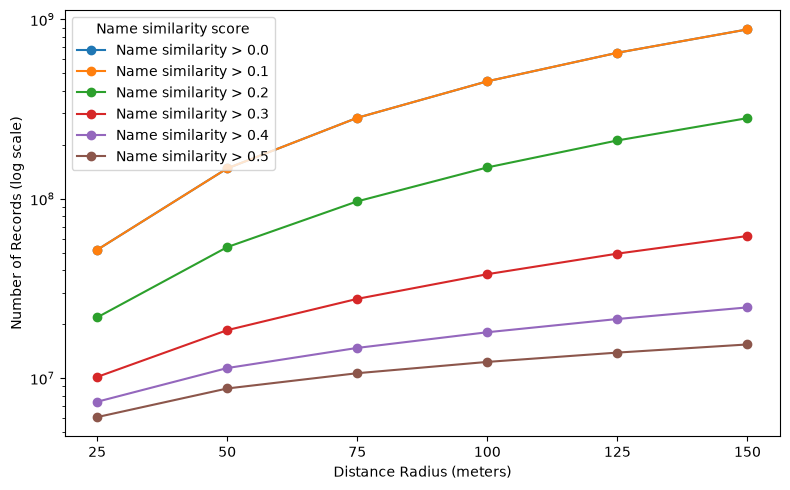

In [45]:
plot_rows([data_by_distance_00, data_by_distance_01, data_by_distance_02, data_by_distance_03, data_by_distance_04, data_by_distance_05])


In [48]:
plot_(data_25_01, output_prefix="filtered_25_01", show=False)
plot_(data_50_01, output_prefix="filtered_50_01", show=False)
plot_(data_75_01, output_prefix="filtered_75_01", show=False)
plot_(data_100_01, output_prefix="filtered_100_01", show=False)
plot_(data_125_01, output_prefix="filtered_125_01", show=False)
plot_(data_150_01, output_prefix="filtered_150_01", show=False)

51,885,689 & 147,572,686 & 282,486,463 & 451,288,407 & 650,849,191 & 878,597,226 & 

In [49]:
plot_(data_25_02, output_prefix="filtered_25_02", show=False)
plot_(data_50_02, output_prefix="filtered_50_02", show=False)
plot_(data_75_02, output_prefix="filtered_75_02", show=False)
plot_(data_100_02, output_prefix="filtered_100_02", show=False)
plot_(data_125_02, output_prefix="filtered_125_02", show=False)
plot_(data_150_02, output_prefix="filtered_150_02", show=False)

21,797,967 & 53,729,309 & 96,653,525 & 149,428,737 & 211,238,149 & 281,320,874 & 

In [50]:
plot_(data_25_03, output_prefix="filtered_25_03", show=False)
plot_(data_50_03, output_prefix="filtered_50_03", show=False)
plot_(data_75_03, output_prefix="filtered_75_03", show=False)
plot_(data_100_03, output_prefix="filtered_100_03", show=False)
plot_(data_125_03, output_prefix="filtered_125_03", show=False)
plot_(data_150_03, output_prefix="filtered_150_03", show=False)

10,151,510 & 18,508,530 & 27,659,515 & 37,960,922 & 49,418,104 & 61,967,264 & 

In [51]:
plot_(data_25_04, output_prefix="filtered_25_04", show=False)
plot_(data_50_04, output_prefix="filtered_50_04", show=False)
plot_(data_75_04, output_prefix="filtered_75_04", show=False)
plot_(data_100_04, output_prefix="filtered_100_04", show=False)
plot_(data_125_04, output_prefix="filtered_125_04", show=False)
plot_(data_150_04, output_prefix="filtered_150_04", show=False)

7,382,984 & 11,378,738 & 14,736,843 & 18,019,041 & 21,355,394 & 24,791,369 & 

In [52]:
plot_(data_25_05, output_prefix="filtered_25_05", show=False)
plot_(data_50_05, output_prefix="filtered_50_05", show=False)
plot_(data_75_05, output_prefix="filtered_75_05", show=False)
plot_(data_100_05, output_prefix="filtered_100_05", show=False)
plot_(data_125_05, output_prefix="filtered_125_05", show=False)
plot_(data_150_05, output_prefix="filtered_150_05", show=False)

6,063,149 & 8,755,695 & 10,652,023 & 12,312,566 & 13,878,045 & 15,406,378 & 

In [53]:
plot_(data_25_06, output_prefix="filtered_25_06", show=False)
plot_(data_50_06, output_prefix="filtered_50_06", show=False)
plot_(data_75_06, output_prefix="filtered_75_06", show=False)
plot_(data_100_06, output_prefix="filtered_100_06", show=False)
plot_(data_125_06, output_prefix="filtered_125_06", show=False)
plot_(data_150_06, output_prefix="filtered_150_06", show=False)

4,946,106 & 6,779,347 & 7,844,362 & 8,657,896 & 9,352,493 & 9,979,283 & 

In [54]:
plot_(data_25_07, output_prefix="filtered_25_07", show=False)
plot_(data_50_07, output_prefix="filtered_50_07", show=False)
plot_(data_75_07, output_prefix="filtered_75_07", show=False)
plot_(data_100_07, output_prefix="filtered_100_07", show=False)
plot_(data_125_07, output_prefix="filtered_125_07", show=False)
plot_(data_150_07, output_prefix="filtered_150_07", show=False)

4,235,328 & 5,620,094 & 6,317,534 & 6,792,145 & 7,161,454 & 7,470,090 & 

In [55]:
plot_(data_25_08, output_prefix="filtered_25_08", show=False)
plot_(data_50_08, output_prefix="filtered_50_08", show=False)
plot_(data_75_08, output_prefix="filtered_75_08", show=False)
plot_(data_100_08, output_prefix="filtered_100_08", show=False)
plot_(data_125_08, output_prefix="filtered_125_08", show=False)
plot_(data_150_08, output_prefix="filtered_150_08", show=False)

3,787,467 & 4,946,581 & 5,488,586 & 5,836,673 & 6,095,089 & 6,302,743 & 

In [56]:
plot_(data_25_09, output_prefix="filtered_25_09", show=False)
plot_(data_50_09, output_prefix="filtered_50_09", show=False)
plot_(data_75_09, output_prefix="filtered_75_09", show=False)
plot_(data_100_09, output_prefix="filtered_100_09", show=False)
plot_(data_125_09, output_prefix="filtered_125_09", show=False)
plot_(data_150_09, output_prefix="filtered_150_09", show=False)

3,417,470 & 4,429,207 & 4,888,398 & 5,177,010 & 5,387,754 & 5,555,130 & 

In [57]:
plot_(data_25_10, output_prefix="filtered_25_10", show=False)
plot_(data_50_10, output_prefix="filtered_50_10", show=False)
plot_(data_75_10, output_prefix="filtered_75_10", show=False)
plot_(data_100_10, output_prefix="filtered_100_10", show=False)
plot_(data_125_10, output_prefix="filtered_125_10", show=False)
plot_(data_150_10, output_prefix="filtered_150_10", show=False)

3,043,228 & 3,926,967 & 4,324,602 & 4,574,080 & 4,756,521 & 4,901,863 & 